# Bike Sharing Demand -- Exploratory Data Analysis

Target value `cnt`

## 1. Import Libraries and Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('darkgrid')
%matplotlib inline
import warnings

warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("data/hour.csv")
df= df.drop(['instant', 'casual', 'registered'], axis= 1)
print(df.shape)
df

(17379, 14)


,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt
0,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0000,16
1,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0000,40
2,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0000,32
3,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0000,13
4,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0000,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17374,2012-12-31,1,1,12,19,0,1,1,2,0.26,0.2576,0.60,0.1642,119
17375,2012-12-31,1,1,12,20,0,1,1,2,0.26,0.2576,0.60,0.1642,89
17376,2012-12-31,1,1,12,21,0,1,1,1,0.26,0.2576,0.60,0.1642,90
17377,2012-12-31,1,1,12,22,0,1,1,1,0.26,0.2727,0.56,0.1343,61


## 2. Data Overview

In [3]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   dteday      17379 non-null  object 
 1   season      17379 non-null  int64  
 2   yr          17379 non-null  int64  
 3   mnth        17379 non-null  int64  
 4   hr          17379 non-null  int64  
 5   holiday     17379 non-null  int64  
 6   weekday     17379 non-null  int64  
 7   workingday  17379 non-null  int64  
 8   weathersit  17379 non-null  int64  
 9   temp        17379 non-null  float64
 10  atemp       17379 non-null  float64
 11  hum         17379 non-null  float64
 12  windspeed   17379 non-null  float64
 13  cnt         17379 non-null  int64  
dtypes: float64(4), int64(9), object(1)
memory usage: 1.9+ MB
None


In [28]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
dteday,17379,731,2011-01-01,24,NaN,NaN,NaN,NaN,NaN,NaN,NaN
season,17379.0,NaN,NaN,NaN,2.50164,1.106918,1.0,2.0,3.0,3.0,4.0
yr,17379.0,NaN,NaN,NaN,0.502561,0.500008,0.0,0.0,1.0,1.0,1.0
mnth,17379.0,NaN,NaN,NaN,6.537775,3.438776,1.0,4.0,7.0,10.0,12.0
hr,17379.0,NaN,NaN,NaN,11.546752,6.914405,0.0,6.0,12.0,18.0,23.0
holiday,17379.0,NaN,NaN,NaN,0.02877,0.167165,0.0,0.0,0.0,0.0,1.0
weekday,17379.0,NaN,NaN,NaN,3.003683,2.005771,0.0,1.0,3.0,5.0,6.0
workingday,17379.0,NaN,NaN,NaN,0.682721,0.465431,0.0,0.0,1.0,1.0,1.0
weathersit,17379.0,NaN,NaN,NaN,1.425283,0.639357,1.0,1.0,1.0,2.0,4.0
temp,17379.0,NaN,NaN,NaN,0.496987,0.192556,0.02,0.34,0.5,0.66,1.0


## 3. Mssing Values / Duplicate Analysis

In [5]:
missing = df.isnull().sum()
m_df = pd.DataFrame({'Columns': missing.index, 'MIssing COunt' : missing.values , 'Missing %': f"{(sum(missing.values)/len(df))*100}%"})
m_df

,Columns,MIssing COunt,Missing %
0,dteday,0,0.0%
1,season,0,0.0%
2,yr,0,0.0%
3,mnth,0,0.0%
4,hr,0,0.0%
5,holiday,0,0.0%
6,weekday,0,0.0%
7,workingday,0,0.0%
8,weathersit,0,0.0%
9,temp,0,0.0%


In [6]:
# Duplicate check 
print(f'Total Number of Duplicate is {df.duplicated(keep='first').sum()}')

Total Number of Duplicate is 0


## 4. Target Variable Analysis


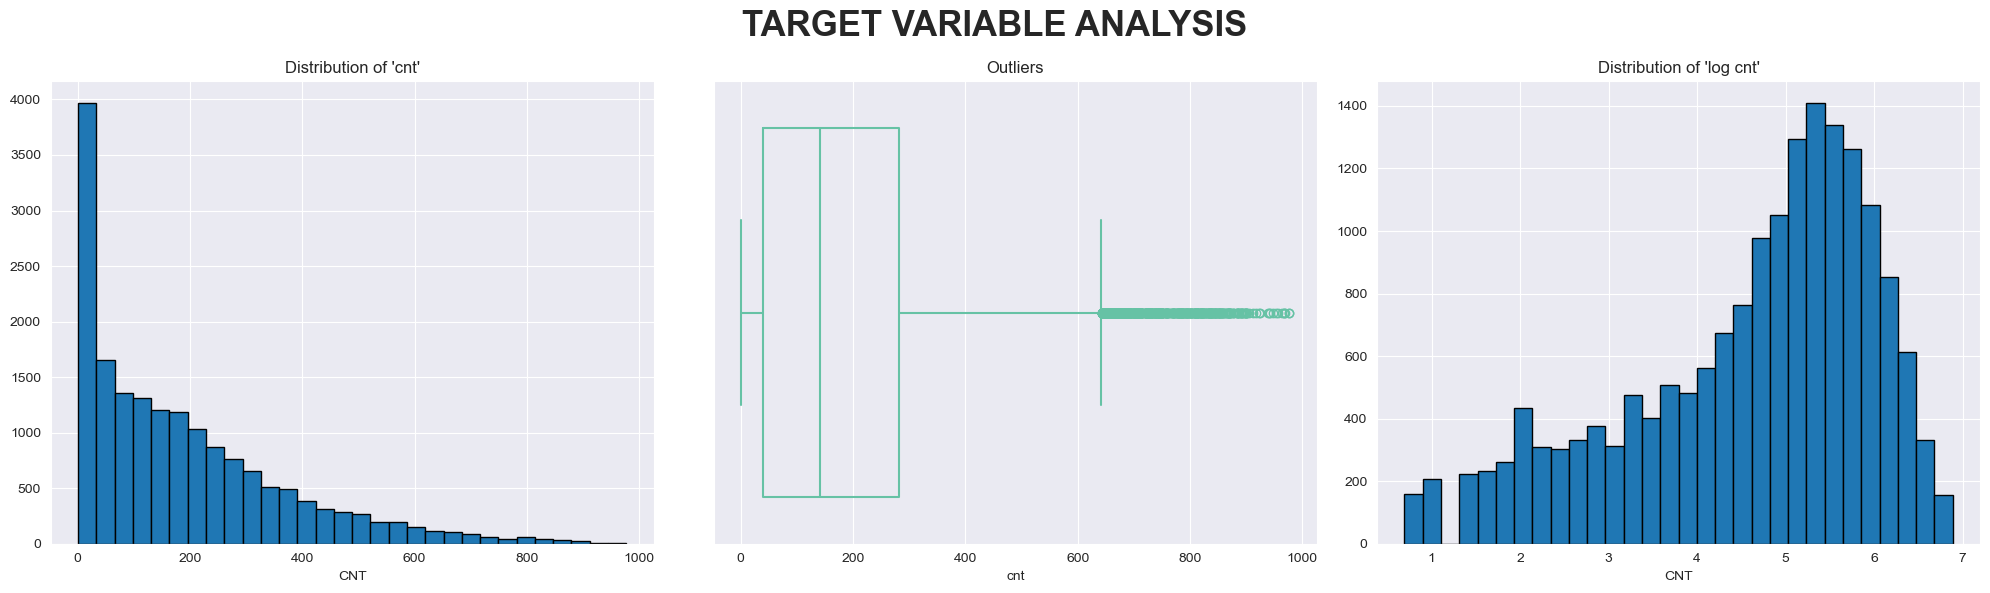

In [7]:
fig, axes = plt.subplots(1, 3, figsize= (20, 6))

axes[0].hist(df['cnt'], bins=30, alpha= 1, edgecolor='black')
axes[0].set_xlabel("CNT");  axes[0].set_title("Distribution of 'cnt'")

sns.boxplot(x= df['cnt'], fill= False, palette='Set2', ax =axes[1])
axes[1].set_title("Outliers")

log = np.log1p(df['cnt'])
axes[2].hist(log , bins=30, alpha= 1, edgecolor='black')
axes[2].set_xlabel("CNT");  axes[2].set_title("Distribution of 'log cnt'")

plt.suptitle("TARGET VARIABLE ANALYSIS", fontweight='bold', fontsize=25)

plt.tight_layout();   plt.show()

## 5 Univariate Analysis -- Numerical Columns

In [8]:
num_col  = [col for col in df.drop(columns=['cnt', 'dteday', 'season', 'mnth', 'hr','yr', 'holiday','workingday','weathersit', 'weekday']) if col in df.columns]
print(len(num_col))

4


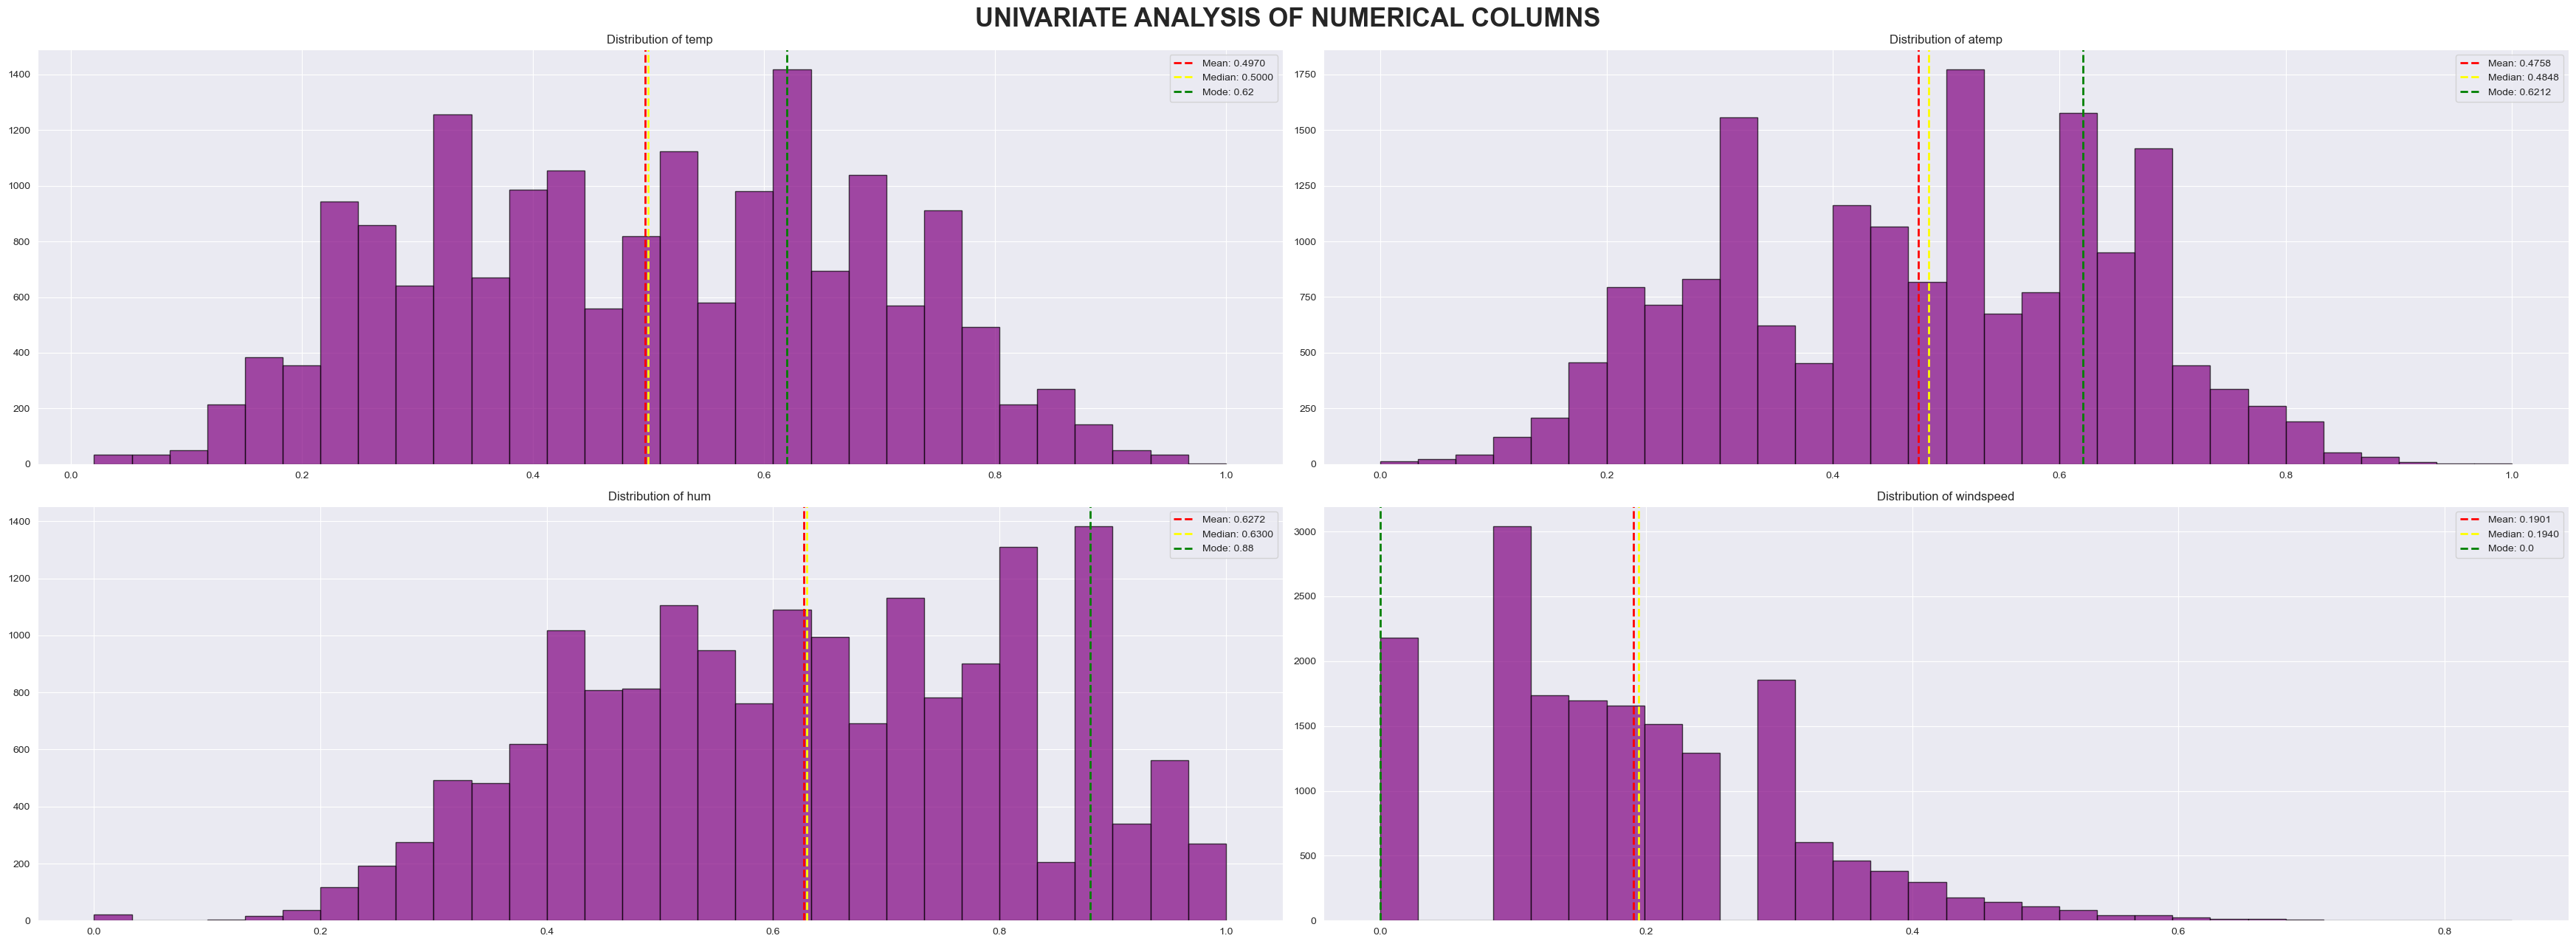

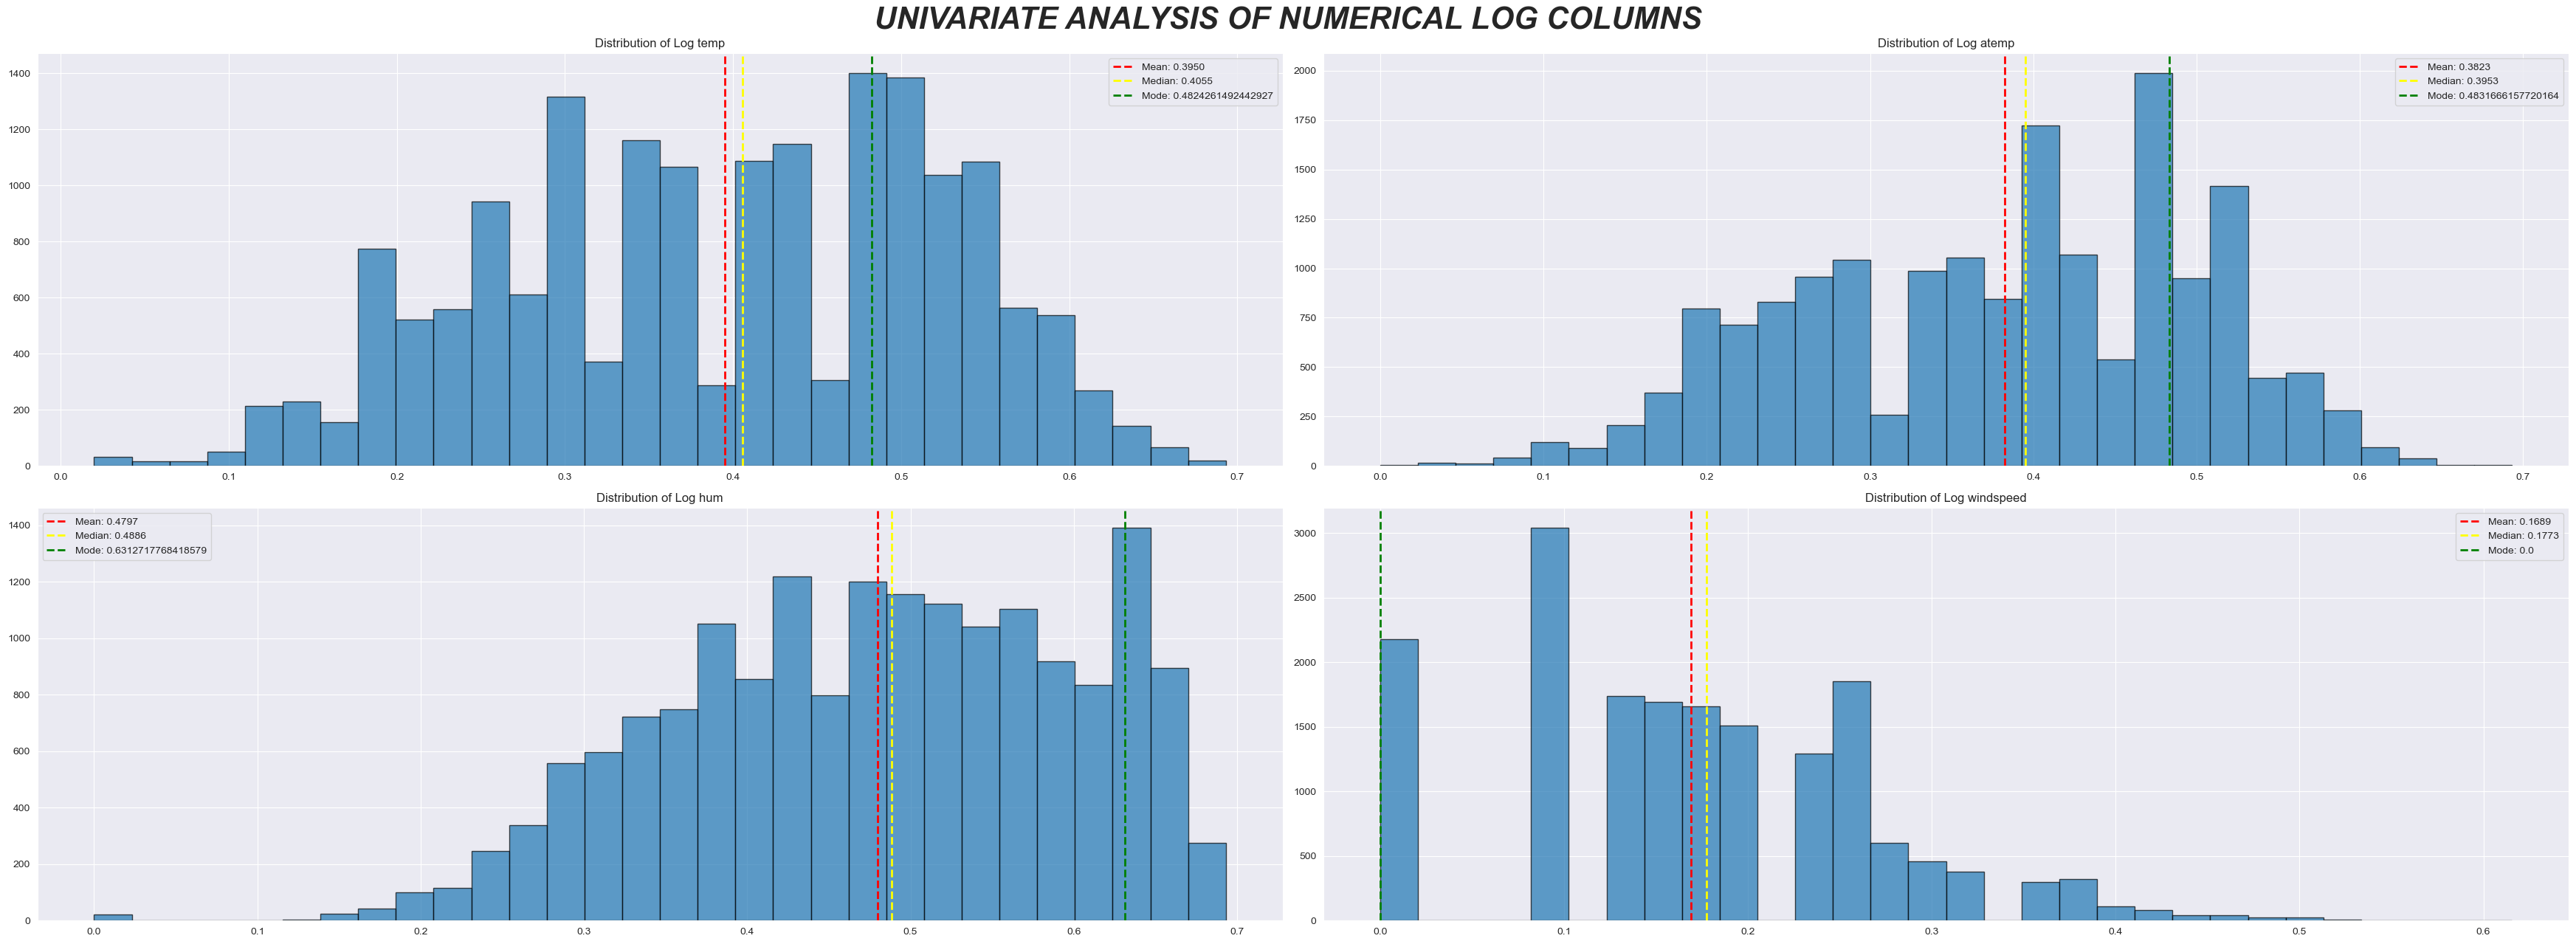

In [9]:
fig, axes = plt.subplots(2, 2, figsize= (35, 13))
axes= axes.flatten()

for i, col in enumerate(num_col):

    axes[i].hist(df[col], bins=30, edgecolor='black', alpha= 0.7, color='purple')
    axes[i].axvline(df[col].mean(), linestyle= '--', color='red',linewidth=2, label= f"Mean: {df[col].mean():.4f}")
    axes[i].axvline(df[col].median(), linestyle= '--', color='yellow',linewidth=2, label= f"Median: {df[col].median():.4f}")
    axes[i].axvline(df[col].mode()[0], linestyle= '--', color='green',linewidth=2, label= f"Mode: {df[col].mode()[0]}")

    axes[i].set_title(f'Distribution of {col}')
    axes[i].legend()
plt.suptitle("UNIVARIATE ANALYSIS OF NUMERICAL COLUMNS", fontweight='bold', fontsize= 25)
plt.tight_layout()
plt.show()


fig, axes = plt.subplots(2,2, figsize= (35, 13))
axes= axes.flatten()


for i, col in enumerate(num_col):
    
    log_col = np.log1p(df[col])
    axes[i].hist(log_col, bins=30, edgecolor='black', alpha= 0.7)
    axes[i].axvline(log_col.mean(), linestyle='--', color='red', linewidth=2, label= f"Mean: {log_col.mean():.4f}")
    axes[i].axvline(log_col.median(),  linestyle='--', color='yellow',linewidth=2, label= f"Median: {log_col.median():.4f}")
    axes[i].axvline(log_col.mode()[0], linestyle= '--', color='green',linewidth=2, label= f"Mode: {log_col.mode()[0]}")

    axes[i].set_title(f'Distribution of Log {col}')
    axes[i].legend()
plt.suptitle("UNIVARIATE ANALYSIS OF NUMERICAL LOG COLUMNS", fontweight='bold', fontstyle='italic', fontsize= 30)
plt.tight_layout()
plt.show()

In [19]:
# for Categorical data
cat_col = [col for col in df.drop(columns=['dteday', 'cnt']).columns if col not in num_col]

print(cat_col)

['season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit']


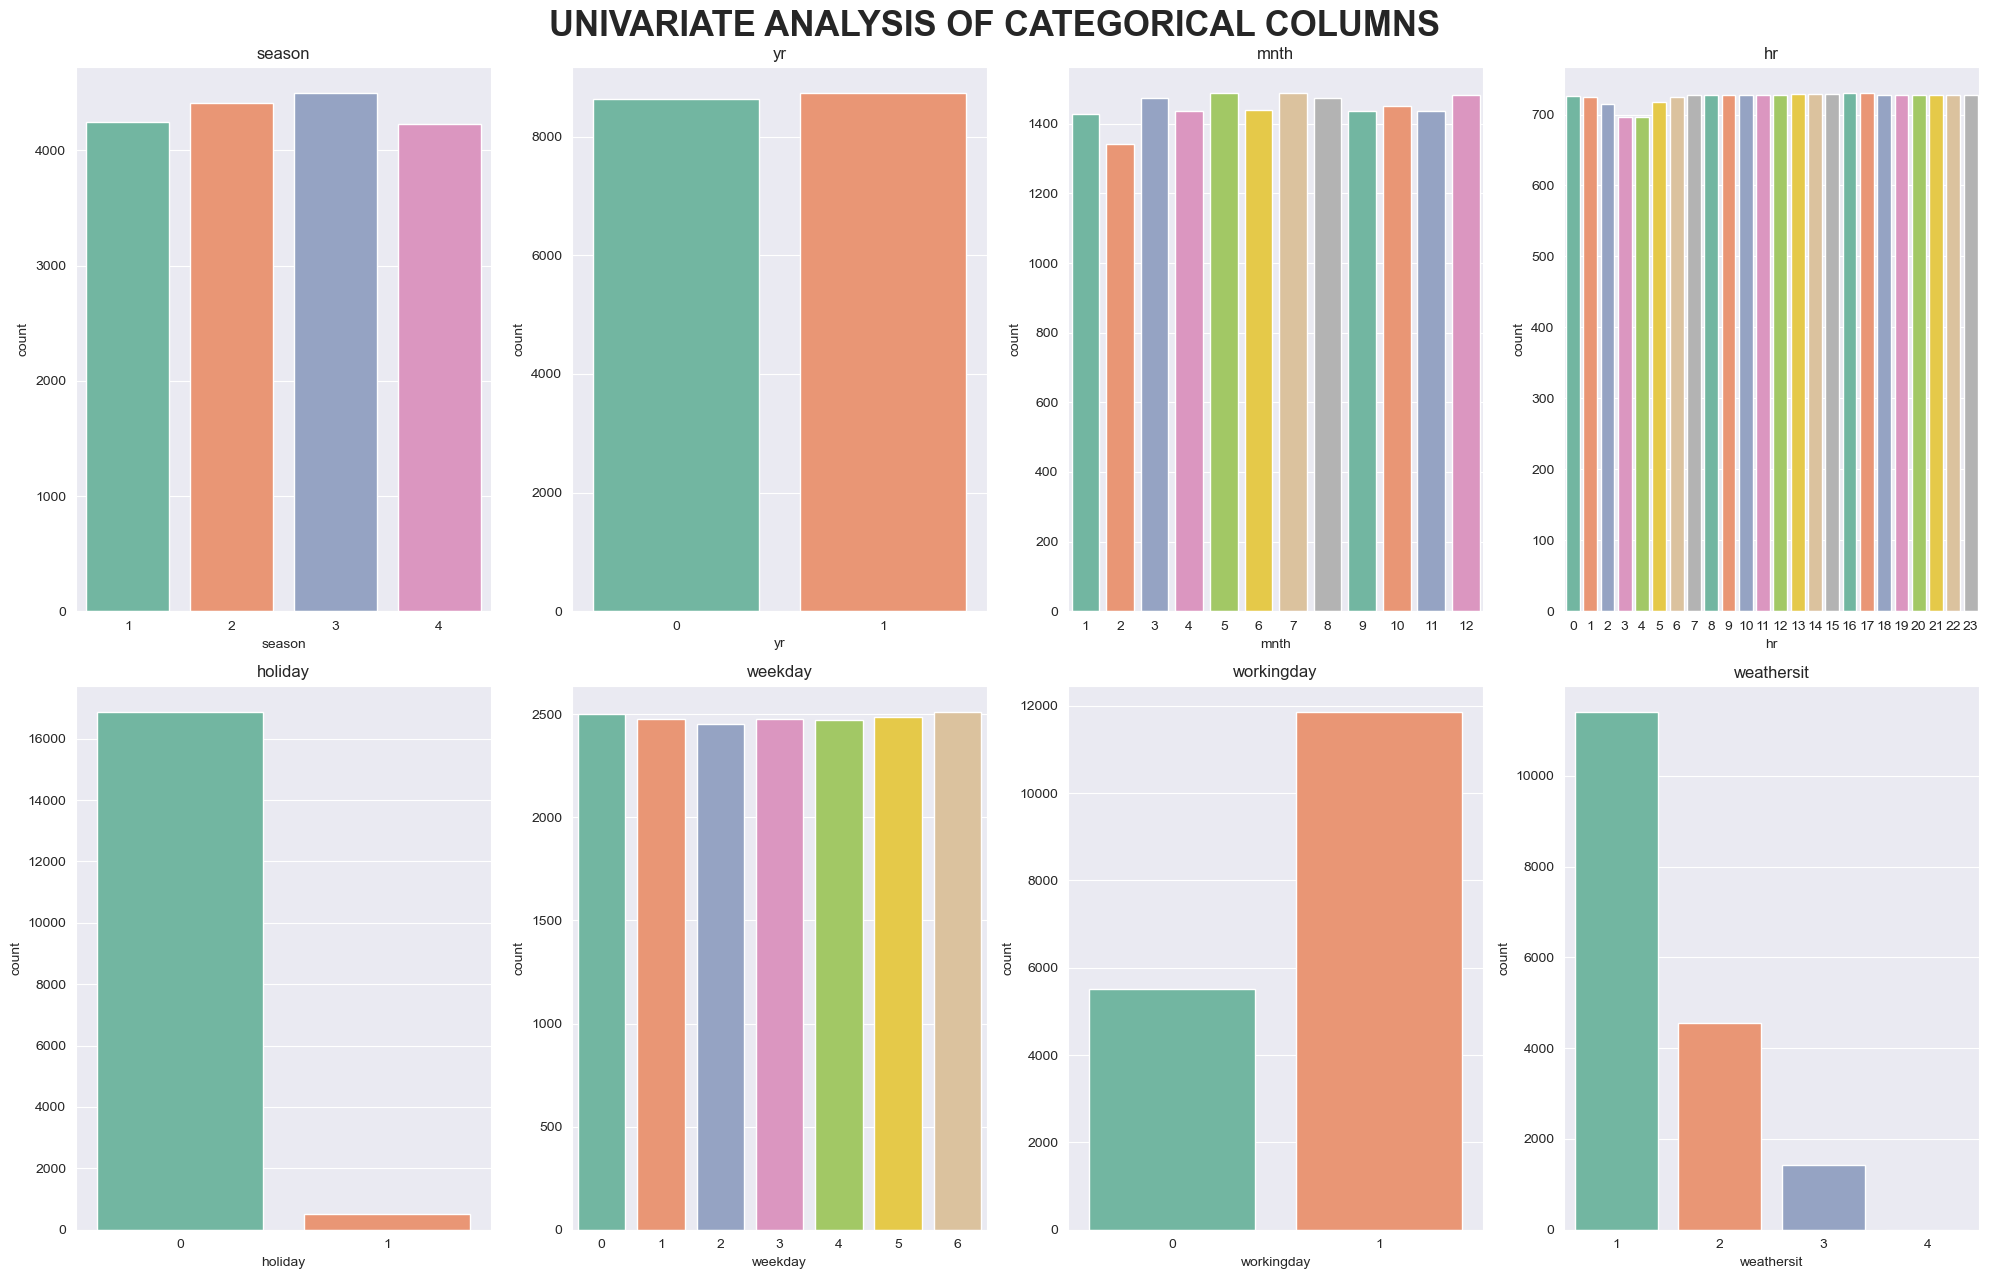

In [27]:
fig, axes = plt.subplots(2, 4, figsize = (20, 13))
axes =axes.flatten()

for i, col in enumerate(cat_col):
    count = df[col].value_counts()
    
    sns.countplot(x=df[col], ax=axes[i], palette='Set2')
    #axes[i].bar(count.index, height =count.values, color='indigo')
    axes[i].set_title(f"{col}")

plt.suptitle("UNIVARIATE ANALYSIS OF CATEGORICAL COLUMNS", fontweight='bold', fontsize= 25)
plt.tight_layout()
plt.show()

## 6 Bivariate Analysis - Target Vs Features

In [ ]:
fig , axes =plt.subplots()